Maximum error = 3.424463e-04


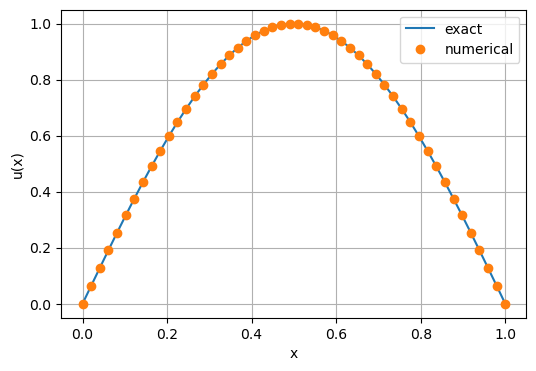

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Grid
# -----------------------------
N = 50
a = 0.0
b = 1.0

x = np.linspace(a, b, N)
dx = x[1] - x[0]

# Interior grid points
x_interior = x[1:-1]
N_interior = len(x_interior)

# -----------------------------
# Source term
# -----------------------------
f = -np.pi**2 * np.sin(np.pi * x_interior)

# -----------------------------
# Build discrete Laplacian
# -----------------------------
main_diag = -2.0 * np.ones(N_interior)
off_diag = 1.0 * np.ones(N_interior - 1)

L = (
    np.diag(main_diag)
    + np.diag(off_diag, k=1)
    + np.diag(off_diag, k=-1)
) / dx**2

# -----------------------------
# Solve L u = f
# -----------------------------
u_interior = np.linalg.solve(L, f)

# -----------------------------
# Reconstruct full solution
# -----------------------------
u = np.zeros(N)
u[0] = 0.0
u[-1] = 0.0
u[1:-1] = u_interior

# Exact solution
u_exact = np.sin(np.pi * x)

# -----------------------------
# Error
# -----------------------------
error = np.linalg.norm(u - u_exact, ord=np.inf)

print(f"Maximum error = {error:.6e}")

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(6, 4))
plt.plot(x, u_exact, label="exact")
plt.plot(x, u, "o", label="numerical")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.legend()
plt.grid(True)
plt.show()

Converged in 179 iterations.


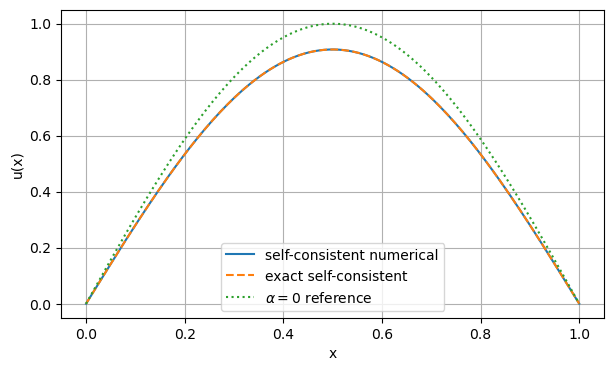

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse import diags
from scipy.sparse.linalg import spsolve


def build_laplacian_dirichlet_1d(n_interior: int, dx: float):
    """
    Build the 1D finite-difference Laplacian with Dirichlet boundaries.
    Unknowns are only the interior grid values.
    """
    main = -2.0 * np.ones(n_interior)
    off = 1.0 * np.ones(n_interior - 1)

    L = diags(
        diagonals=[off, main, off],
        offsets=[-1, 0, 1],
        format="csr",
    ) / dx**2

    return L


def source_term(x: np.ndarray, u: np.ndarray, alpha: float) -> np.ndarray:
    """
    Mild self-consistent source term:

        f(x, u) = -pi^2 sin(pi x) + alpha u

    This keeps the problem simple enough for fixed-point iteration.
    """
    return -np.pi**2 * np.sin(np.pi * x) + alpha * u


def solve_self_consistent_poisson_1d(
    n_grid: int = 200,
    alpha: float = 1.0,
    tol: float = 1.0e-10,
    max_iter: int = 500,
    mixing: float = 0.1,
):
    """
    Solve

        u'' = -pi^2 sin(pi x) + alpha u

    on [0, 1], with

        u(0) = 0,
        u(1) = 0.

    Uses fixed-point iteration with linear mixing:

        L u_solved^(k+1) = f(x, u^k)

        u^(k+1) = (1 - beta) u^k + beta u_solved^(k+1)
    """

    x = np.linspace(0.0, 1.0, n_grid)
    dx = x[1] - x[0]

    x_interior = x[1:-1]
    n_interior = len(x_interior)

    L = build_laplacian_dirichlet_1d(n_interior, dx)

    u_old = np.zeros(n_interior)
    history = []

    for k in range(max_iter):
        rhs = source_term(x_interior, u_old, alpha)

        # Poisson solve: solve L u = rhs
        u_solved = spsolve(L, rhs)

        # Linear mixing
        u_new = (1.0 - mixing) * u_old + mixing * u_solved

        err = np.linalg.norm(u_new - u_old, ord=np.inf)
        history.append(err)

        if err < tol:
            print(f"Converged in {k + 1} iterations.")
            break

        u_old = u_new

    else:
        print("Warning: self-consistent loop did not converge.")

    u = np.zeros(n_grid)
    u[1:-1] = u_new

    return x, u, history


alpha=1.0

x, u, history = solve_self_consistent_poisson_1d(
    n_grid=200,
    alpha=alpha,
    tol=1.0e-10,
    max_iter=500,
    mixing=0.1,
)

u_reference = np.sin(np.pi * x)
u_exact_sc = (np.pi**2 / (np.pi**2 + alpha)) * np.sin(np.pi * x)

plt.figure(figsize=(7, 4))
plt.plot(x, u, label="self-consistent numerical")
plt.plot(x, u_exact_sc, "--", label="exact self-consistent")
plt.plot(x, u_reference, ":", label=r"$\alpha=0$ reference")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.legend()
plt.grid(True)
plt.show()

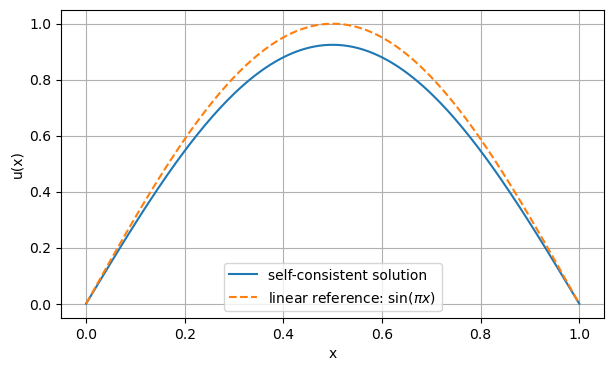

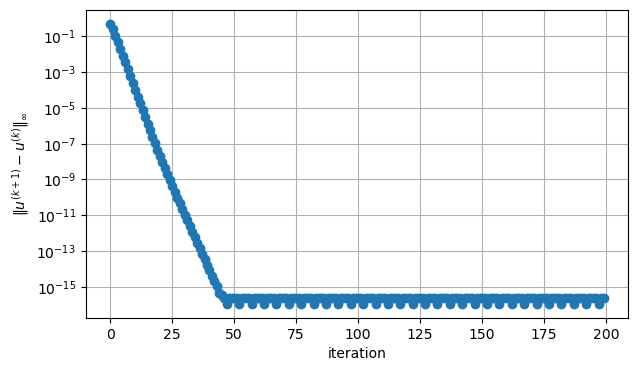

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse import diags
from scipy.sparse.linalg import spsolve


def build_laplacian_dirichlet_1d(n_interior: int, dx: float):
    """
    Build the 1D finite-difference Laplacian on the interior nodes.

    The boundary conditions are Dirichlet, so the boundary values are
    not included as unknowns.

    The operator corresponds to

        u''(x_i) ≈ (u_{i-1} - 2u_i + u_{i+1}) / dx**2

    for i = 1, ..., N-2.
    """
    main = -2.0 * np.ones(n_interior)
    off = 1.0 * np.ones(n_interior - 1)

    L = diags(
        diagonals=[off, main, off],
        offsets=[-1, 0, 1],
        format="csr",
    ) / dx**2

    return L


def source_term(x: np.ndarray, u: np.ndarray, alpha: float) -> np.ndarray:
    """
    Self-consistent source term.

    f(x, u) = -pi^2 sin(pi x) + alpha u^2
    """
    return -np.pi**2 * np.sin(np.pi * x) + alpha * u**2


def solve_self_consistent_poisson_1d(
    n_grid: int = 200,
    alpha: float = 1.0,
    tol: float = 1.0e-10,
    max_iter: int = 200,
    mixing: float = 0.5,
):
    """
    Solve the nonlinear/self-consistent 1D Poisson problem

        u'' = -pi^2 sin(pi x) + alpha u^2

    on x in [0, 1], subject to

        u(0) = 0,
        u(1) = 0.

    Uses fixed-point iteration with linear mixing.

    The update is:

        L u_new = f(x, u_old)

    followed by

        u_next = (1 - mixing) u_old + mixing u_new.

    Parameters
    ----------
    n_grid:
        Total number of grid points, including boundary points.

    alpha:
        Strength of the nonlinear self-consistent term.

    tol:
        Convergence tolerance for the infinity norm of the update.

    max_iter:
        Maximum number of self-consistent iterations.

    mixing:
        Linear mixing parameter. Smaller values are more stable but slower.

    Returns
    -------
    x:
        Full grid including boundary points.

    u:
        Full solution including boundary values.

    history:
        List of update errors at each iteration.
    """

    # -----------------------------
    # Grid
    # -----------------------------
    x = np.linspace(0.0, 1.0, n_grid)
    dx = x[1] - x[0]

    x_interior = x[1:-1]
    n_interior = len(x_interior)

    # -----------------------------
    # Operator
    # -----------------------------
    L = build_laplacian_dirichlet_1d(n_interior, dx)

    # -----------------------------
    # Initial guess
    # -----------------------------
    u_old = np.zeros(n_interior)

    history = []

    for k in range(max_iter):
        # Compute source from current guess
        rhs = source_term(x_interior, u_old, alpha)

        # Solve L u_solved = rhs
        # This is the Poisson solve.
        u_solved = spsolve(L, rhs)

        # Linear mixing for stability
        u_new = (1.0 - mixing) * u_old + mixing * u_solved

        # Convergence check
        err = np.linalg.norm(u_new - u_old, ord=np.inf)
        history.append(err)

        if err < tol:
            print(f"Converged in {k + 1} iterations.")
            break

        u_old = u_new

    else:
        print("Warning: self-consistent loop did not converge.")

    # -----------------------------
    # Reconstruct full solution
    # -----------------------------
    u = np.zeros(n_grid)
    u[0] = 0.0
    u[-1] = 0.0
    u[1:-1] = u_new

    return x, u, history


# -----------------------------
# Run example
# -----------------------------
x, u, history = solve_self_consistent_poisson_1d(
    n_grid=200,
    alpha=1.0,
    tol=1.0e-16,
    max_iter=200,
    mixing=0.5,
)

# Reference solution for alpha = 0
u_linear = np.sin(np.pi * x)

# -----------------------------
# Plot solution
# -----------------------------
plt.figure(figsize=(7, 4))
plt.plot(x, u, label="self-consistent solution")
plt.plot(x, u_linear, "--", label=r"linear reference: $\sin(\pi x)$")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# Plot convergence
# -----------------------------
plt.figure(figsize=(7, 4))
plt.semilogy(history, marker="o")
plt.xlabel("iteration")
plt.ylabel(r"$\|u^{(k+1)} - u^{(k)}\|_\infty$")
plt.grid(True)
plt.show()

## Example: Self-Consistent Poisson Solver for a 1D Semiconductor Junction

We now solve an actual semiconductor electrostatics problem: a one-dimensional abrupt silicon $p$-$n$ junction at thermal equilibrium.

The goal is to solve Poisson's equation, but with the charge density determined by the electrostatic potential itself. This is why the problem is self-consistent.

## Physical Model

Let $\phi(x)$ be the electrostatic potential. The one-dimensional Poisson equation is

$$
\frac{\mathrm{d}^2 \phi}{\mathrm{d}x^2}
=
-\frac{\rho(x)}{\varepsilon_s},
$$

where $\varepsilon_s$ is the semiconductor permittivity and $\rho(x)$ is the charge density.

For a semiconductor,

$$
\rho(x)
=
q
\left[
p(x)
-
n(x)
+
N_D^+(x)
-
N_A^-(x)
\right],
$$

where $n(x)$ is the electron density, $p(x)$ is the hole density, $N_D^+(x)$ is the ionized donor density, and $N_A^-(x)$ is the ionized acceptor density.

Assuming nondegenerate Boltzmann statistics,

$$
n(x)
=
n_i e^{\phi(x)/V_T},
\qquad
p(x)
=
n_i e^{-\phi(x)/V_T},
$$

where

$$
V_T
=
\frac{k_B T}{q}
$$

is the thermal voltage.

Define the dimensionless potential

$$
y(x)
=
\frac{\phi(x)}{V_T}.
$$

Then

$$
n(x)
=
n_i e^{y(x)},
\qquad
p(x)
=
n_i e^{-y(x)}.
$$

Substituting into Poisson's equation gives

$$
\frac{\mathrm{d}^2 y}{\mathrm{d}x^2}
=
-\frac{q}{\varepsilon_s V_T}
\left[
n_i e^{-y(x)}
-
n_i e^{y(x)}
+
N_D^+(x)
-
N_A^-(x)
\right].
$$

This is self-consistent because $y(x)$ determines $n(x)$ and $p(x)$, while $n(x)$ and $p(x)$ determine the charge density that sources $y(x)$.

## Abrupt Junction Doping Profile

For an abrupt $p$-$n$ junction,

$$
C(x)
=
N_D^+(x)-N_A^-(x)
=
\begin{cases}
-N_A, & x < 0, \\
+N_D, & x > 0.
\end{cases}
$$

Therefore, the self-consistent Poisson equation becomes

$$
\frac{\mathrm{d}^2 y}{\mathrm{d}x^2}
=
-\frac{q}{\varepsilon_s V_T}
\left[
n_i e^{-y(x)}
-
n_i e^{y(x)}
+
C(x)
\right].
$$

Equivalently,

$$
\frac{\mathrm{d}^2 y}{\mathrm{d}x^2}
+
\frac{q}{\varepsilon_s V_T}
\left[
n_i e^{-y(x)}
-
n_i e^{y(x)}
+
C(x)
\right]
=
0.
$$

This is a nonlinear boundary-value problem.

## Boundary Conditions

Far from the junction, the semiconductor is locally charge-neutral. Therefore,

$$
p-n+C=0.
$$

Using

$$
p-n
=
n_i e^{-y}
-
n_i e^y
=
-2n_i \sinh y,
$$

we get

$$
-2n_i\sinh y + C = 0.
$$

Therefore,

$$
\sinh y
=
\frac{C}{2n_i},
$$

so the bulk dimensionless potential is

$$
y_{\mathrm{bulk}}
=
\sinh^{-1}
\left(
\frac{C}{2n_i}
\right).
$$

For the left $p$-type side,

$$
y_L
=
\sinh^{-1}
\left(
\frac{-N_A}{2n_i}
\right).
$$

For the right $n$-type side,

$$
y_R
=
\sinh^{-1}
\left(
\frac{N_D}{2n_i}
\right).
$$

Thus the boundary-value problem is

$$
\begin{aligned}
\frac{\mathrm{d}^2 y}{\mathrm{d}x^2}
+
\frac{q}{\varepsilon_s V_T}
\left[
n_i e^{-y(x)}
-
n_i e^{y(x)}
+
C(x)
\right]
&=
0,
\\[0.75em]
\text{subject to}\qquad
y(-L/2) &= y_L,
\\
y(L/2) &= y_R.
\end{aligned}
$$

The built-in potential is

$$
V_{\mathrm{bi}}
=
\phi_R-\phi_L
=
V_T(y_R-y_L).
$$

## Discretized Residual

Let $x_i$ be the grid points and let $y_i \approx y(x_i)$.

The second derivative is approximated by

$$
\frac{\mathrm{d}^2 y}{\mathrm{d}x^2}
\bigg|_{x=x_i}
\approx
\frac{
y_{i-1}
-
2y_i
+
y_{i+1}
}{\Delta x^2}.
$$

Define

$$
\gamma
=
\frac{q}{\varepsilon_s V_T}.
$$

The nonlinear residual at each interior grid point is

$$
R_i(\mathbf{y})
=
\frac{
y_{i-1}
-
2y_i
+
y_{i+1}
}{\Delta x^2}
+
\gamma
\left[
n_i e^{-y_i}
-
n_i e^{y_i}
+
C_i
\right].
$$

The numerical problem is to find $\mathbf{y}$ such that

$$
\mathbf{R}(\mathbf{y})=\mathbf{0}.
$$

This is no longer a simple linear solve. It is a nonlinear system.

## Newton Method

Newton's method linearizes the residual around the current guess $\mathbf{y}^{(k)}$:

$$
\mathbf{R}
\left(
\mathbf{y}^{(k)}+\Delta \mathbf{y}^{(k)}
\right)
\approx
\mathbf{R}
\left(
\mathbf{y}^{(k)}
\right)
+
J
\left(
\mathbf{y}^{(k)}
\right)
\Delta \mathbf{y}^{(k)}.
$$

We choose $\Delta \mathbf{y}^{(k)}$ so that the linearized residual becomes zero:

$$
J
\left(
\mathbf{y}^{(k)}
\right)
\Delta \mathbf{y}^{(k)}
=
-
\mathbf{R}
\left(
\mathbf{y}^{(k)}
\right).
$$

Then we update

$$
\mathbf{y}^{(k+1)}
=
\mathbf{y}^{(k)}
+
\lambda
\Delta \mathbf{y}^{(k)},
$$

where $0<\lambda\le 1$ is a damping factor.

The Jacobian matrix is tridiagonal. The diagonal entries are

$$
\frac{\partial R_i}{\partial y_i}
=
-\frac{2}{\Delta x^2}
+
\gamma
\left[
-n_i e^{-y_i}
-
n_i e^{y_i}
\right],
$$

and the off-diagonal entries are

$$
\frac{\partial R_i}{\partial y_{i-1}}
=
\frac{1}{\Delta x^2},
\qquad
\frac{\partial R_i}{\partial y_{i+1}}
=
\frac{1}{\Delta x^2}.
$$

So each Newton step solves a sparse linear system,

$$
J(\mathbf{y}^{(k)})
\Delta \mathbf{y}^{(k)}
=
-
\mathbf{R}(\mathbf{y}^{(k)}),
$$

but the full problem is nonlinear because $J$ and $\mathbf{R}$ depend on $\mathbf{y}$.

In [7]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse import diags
from scipy.sparse.linalg import spsolve


# ------------------------------------------------------------
# Physical constants
# ------------------------------------------------------------
q = 1.602176634e-19          # C
k_B = 1.380649e-23           # J/K
eps0 = 8.8541878128e-12      # F/m

T = 300.0                    # K
V_T = k_B * T / q            # thermal voltage, V

eps_r_si = 11.7
eps_s = eps_r_si * eps0      # silicon permittivity, F/m

# Intrinsic carrier density for Si at 300 K
# 1e10 cm^-3 = 1e16 m^-3
n_i = 1.0e16                 # m^-3


# ------------------------------------------------------------
# Device parameters
# ------------------------------------------------------------
L = 2.0e-6                   # total device length, m
N_grid = 801                 # total grid points

# Doping
# 1e15 cm^-3 = 1e21 m^-3
N_A = 1.0e21                 # m^-3
N_D = 1.0e21                 # m^-3


# ------------------------------------------------------------
# Grid
# ------------------------------------------------------------
x = np.linspace(-L/2, L/2, N_grid)
dx = x[1] - x[0]

# Net doping C(x) = ND - NA
C = np.where(x < 0.0, -N_A, N_D)


# ------------------------------------------------------------
# Boundary conditions from charge-neutral bulk
# ------------------------------------------------------------
y_left = np.arcsinh((-N_A) / (2.0 * n_i))
y_right = np.arcsinh((N_D) / (2.0 * n_i))

print(f"V_T = {V_T:.4f} V")
print(f"y_left  = {y_left:.4f}")
print(f"y_right = {y_right:.4f}")
print(f"phi_left  = {V_T * y_left:.4f} V")
print(f"phi_right = {V_T * y_right:.4f} V")
print(f"built-in voltage = {V_T * (y_right - y_left):.4f} V")


# ------------------------------------------------------------
# Interior unknowns
# ------------------------------------------------------------
x_int = x[1:-1]
C_int = C[1:-1]
N_int = len(x_int)

gamma = q / (eps_s * V_T)


def safe_exp(y):
    """
    Prevent numerical overflow in exp for extreme guesses.
    This is usually not needed for the chosen parameters,
    but it makes Newton more robust.
    """
    return np.exp(np.clip(y, -100.0, 100.0))


def residual(y_int):
    """
    Nonlinear residual R(y) = 0.

    Equation:

        y'' + gamma [n_i exp(-y) - n_i exp(y) + C] = 0

    Discretized at interior nodes.
    """
    y_full = np.empty(N_grid)
    y_full[0] = y_left
    y_full[-1] = y_right
    y_full[1:-1] = y_int

    lap = (y_full[:-2] - 2.0 * y_full[1:-1] + y_full[2:]) / dx**2

    source = n_i * safe_exp(-y_int) - n_i * safe_exp(y_int) + C_int

    R = lap + gamma * source

    return R


def jacobian(y_int):
    """
    Jacobian of the nonlinear residual.

    R_i =
        (y_{i-1} - 2 y_i + y_{i+1}) / dx^2
        + gamma [n_i exp(-y_i) - n_i exp(y_i) + C_i]

    Therefore,

        dR_i/dy_i =
            -2/dx^2
            + gamma [-n_i exp(-y_i) - n_i exp(y_i)]

        dR_i/dy_{i-1} = 1/dx^2
        dR_i/dy_{i+1} = 1/dx^2
    """
    main = (
        -2.0 / dx**2
        + gamma * (-n_i * safe_exp(-y_int) - n_i * safe_exp(y_int))
    )

    off = np.ones(N_int - 1) / dx**2

    J = diags(
        diagonals=[off, main, off],
        offsets=[-1, 0, 1],
        format="csr",
    )

    return J


def solve_newton(
    max_iter=100,
    tol=1.0e-8,
    verbose=True,
):
    """
    Newton solve for the self-consistent Poisson-Boltzmann equation.

    At each step:

        J(y^k) delta y = -R(y^k)

        y^{k+1} = y^k + lambda delta y

    A simple damping / line search is used for stability.
    """

    # Initial guess: linear interpolation between bulk boundary values.
    y = np.linspace(y_left, y_right, N_grid)[1:-1].copy()

    history = []

    R = residual(y)
    norm_R = np.linalg.norm(R, ord=np.inf)
    history.append(norm_R)

    if verbose:
        print(f"iter {0:3d}: residual = {norm_R:.6e}")

    for k in range(1, max_iter + 1):
        J = jacobian(y)

        # Newton correction
        delta = spsolve(J, -R)

        # Damped Newton line search
        damping = 1.0
        accepted = False

        for _ in range(20):
            y_trial = y + damping * delta
            R_trial = residual(y_trial)
            norm_trial = np.linalg.norm(R_trial, ord=np.inf)

            if norm_trial < norm_R:
                accepted = True
                break

            damping *= 0.5

        if not accepted:
            raise RuntimeError("Newton line search failed.")

        y = y_trial
        R = R_trial
        norm_R = norm_trial
        history.append(norm_R)

        if verbose:
            print(
                f"iter {k:3d}: residual = {norm_R:.6e}, "
                f"damping = {damping:.3e}"
            )

        if norm_R < tol:
            if verbose:
                print("Converged.")
            break

    else:
        print("Warning: Newton solver did not converge.")

    # Reconstruct full solution
    y_full = np.empty(N_grid)
    y_full[0] = y_left
    y_full[-1] = y_right
    y_full[1:-1] = y

    return y_full, np.array(history)


# ------------------------------------------------------------
# Solve
# ------------------------------------------------------------
y, history = solve_newton(
    max_iter=100,
    tol=1.0e-8,
    verbose=True,
)

phi = V_T * y

n = n_i * safe_exp(y)
p = n_i * safe_exp(-y)
rho = q * (p - n + C)

E = -np.gradient(phi, dx)


# ------------------------------------------------------------
# Plots
# ------------------------------------------------------------
plt.figure(figsize=(7, 4))
plt.plot(x * 1e6, phi)
plt.xlabel(r"$x$ ($\mu$m)")
plt.ylabel(r"$\phi(x)$ (V)")
plt.title("Electrostatic potential")
plt.grid(True)
plt.show()


plt.figure(figsize=(7, 4))
plt.semilogy(x * 1e6, n / 1e6, label=r"$n$")
plt.semilogy(x * 1e6, p / 1e6, label=r"$p$")
plt.xlabel(r"$x$ ($\mu$m)")
plt.ylabel(r"carrier density (cm$^{-3}$)")
plt.title("Carrier densities")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(7, 4))
plt.plot(x * 1e6, rho)
plt.xlabel(r"$x$ ($\mu$m)")
plt.ylabel(r"$\rho(x)$ (C/m$^3$)")
plt.title("Charge density")
plt.grid(True)
plt.show()


plt.figure(figsize=(7, 4))
plt.plot(x * 1e6, E)
plt.xlabel(r"$x$ ($\mu$m)")
plt.ylabel(r"$E(x)$ (V/m)")
plt.title("Electric field")
plt.grid(True)
plt.show()


plt.figure(figsize=(7, 4))
plt.semilogy(history, marker="o")
plt.xlabel("Newton iteration")
plt.ylabel(r"$\|R(y)\|_\infty$")
plt.title("Newton convergence")
plt.grid(True)
plt.show()

V_T = 0.0259 V
y_left  = -11.5129
y_right = 11.5129
phi_left  = -0.2976 V
phi_right = 0.2976 V
built-in voltage = 0.5953 V
iter   0: residual = 5.982486e+13
iter   1: residual = 2.991243e+13, damping = 5.000e-01
iter   2: residual = 1.597659e+13, damping = 1.000e+00
iter   3: residual = 1.333613e+12, damping = 1.000e+00
iter   4: residual = 9.145463e+09, damping = 1.000e+00
iter   5: residual = 4.192119e+05, damping = 1.000e+00
iter   6: residual = 5.247041e+02, damping = 1.000e+00
iter   7: residual = 5.245078e+02, damping = 5.000e-01
iter   8: residual = 4.753691e+02, damping = 1.000e+00


RuntimeError: Newton line search failed.

## More Robust Solver: Gummel Iteration for the 1D Semiconductor Poisson Problem

The Newton method can fail if the initial guess is poor, especially for an abrupt junction. A more stable first implementation is a Gummel-style self-consistent iteration.

The nonlinear equation is

$$
\frac{\mathrm{d}^2 y}{\mathrm{d}x^2}
+
\gamma
\left[
n_i e^{-y}
-
n_i e^y
+
C(x)
\right]
=
0,
$$

where

$$
y(x)=\frac{\phi(x)}{V_T},
\qquad
\gamma=
\frac{q}{\varepsilon_s V_T}.
$$

Define the nonlinear source term

$$
S(y,x)
=
n_i e^{-y}
-
n_i e^y
+
C(x).
$$

Then the equation is

$$
\frac{\mathrm{d}^2 y}{\mathrm{d}x^2}
+
\gamma S(y,x)
=
0.
$$

At iteration $k$, linearize $S(y,x)$ around the old solution $y^{(k)}$:

$$
S(y^{(k+1)},x)
\approx
S(y^{(k)},x)
+
S'(y^{(k)},x)
\left[
y^{(k+1)}-y^{(k)}
\right].
$$

The derivative is

$$
S'(y,x)
=
-n_i e^{-y}
-
n_i e^y.
$$

Substituting into Poisson's equation gives a linear problem for $y^{(k+1)}$:

$$
\frac{\mathrm{d}^2 y^{(k+1)}}{\mathrm{d}x^2}
+
\gamma
S'(y^{(k)},x)
y^{(k+1)}
=
-\gamma S(y^{(k)},x)
+
\gamma
S'(y^{(k)},x)
y^{(k)}.
$$

This is still self-consistent, but each iteration solves a better-conditioned linearized Poisson problem.

After solving for $y_{\mathrm{solve}}^{(k+1)}$, use under-relaxation:

$$
y^{(k+1)}
=
(1-\beta)y^{(k)}
+
\beta y_{\mathrm{solve}}^{(k+1)}.
$$

Here $0<\beta\le 1$ is the mixing parameter. Smaller $\beta$ gives slower but more stable convergence.




V_T = 0.025852 V
y_left  = -11.512925
y_right = 11.512925
phi_left  = -0.297632 V
phi_right = 0.297632 V
built-in voltage = 0.595264 V
iter     0: update = 3.327122e-01, residual = 5.683361e+13
iter     1: update = 3.104631e-01, residual = 5.399193e+13
iter     2: update = 2.891419e-01, residual = 5.129234e+13
iter     3: update = 2.688085e-01, residual = 4.872772e+13
iter     4: update = 2.495249e-01, residual = 4.629133e+13
iter     5: update = 2.313405e-01, residual = 4.397677e+13
iter     6: update = 2.142866e-01, residual = 4.177793e+13
iter     7: update = 1.983738e-01, residual = 3.968903e+13
iter     8: update = 1.835920e-01, residual = 3.770458e+13
iter     9: update = 1.699126e-01, residual = 3.581935e+13
iter    50: update = 1.260613e-02, residual = 4.373061e+12
iter   100: update = 9.141889e-04, residual = 3.364851e+11
iter   150: update = 7.002984e-05, residual = 2.589083e+10
iter   200: update = 5.386603e-06, residual = 1.992170e+09
iter   250: update = 4.144611e-07, resi

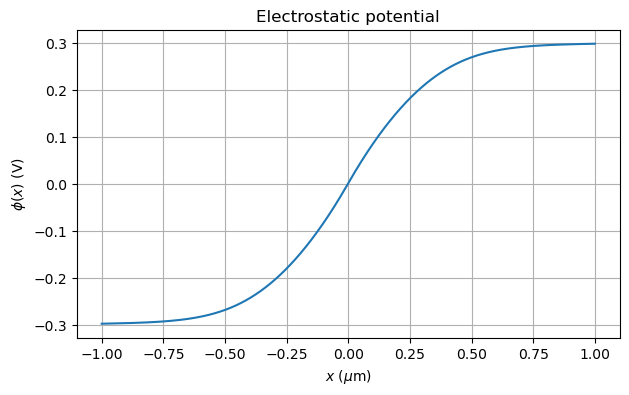

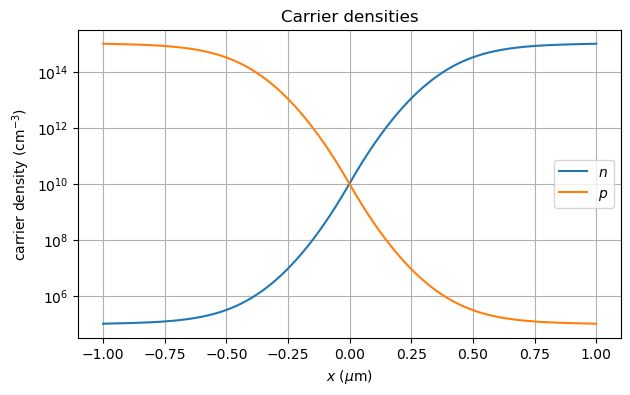

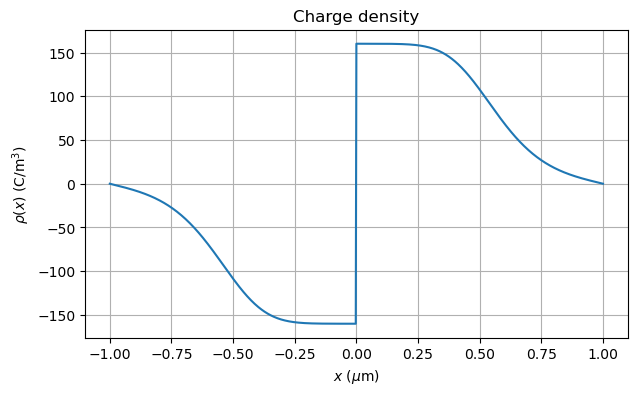

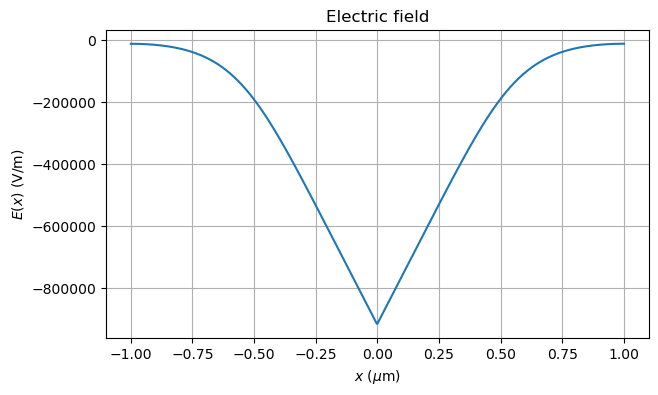

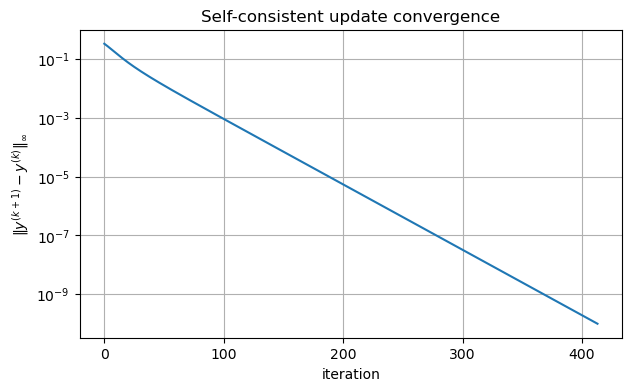

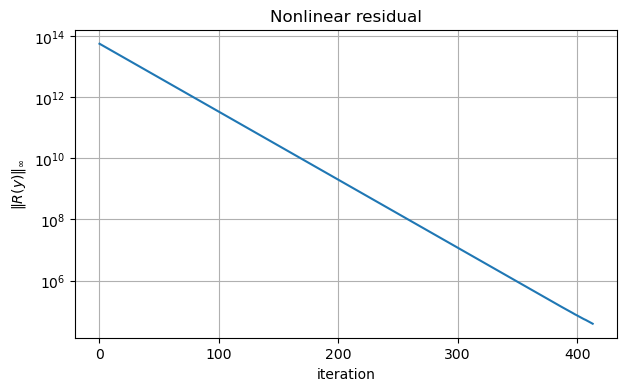

In [8]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse import diags
from scipy.sparse.linalg import spsolve


# ------------------------------------------------------------
# Physical constants
# ------------------------------------------------------------
q = 1.602176634e-19
k_B = 1.380649e-23
eps0 = 8.8541878128e-12

T = 300.0
V_T = k_B * T / q

eps_r_si = 11.7
eps_s = eps_r_si * eps0

# Silicon intrinsic carrier density at 300 K
# 1e10 cm^-3 = 1e16 m^-3
n_i = 1.0e16


# ------------------------------------------------------------
# Device parameters
# ------------------------------------------------------------
L = 2.0e-6
N_grid = 801

# Use moderate doping first.
# 1e15 cm^-3 = 1e21 m^-3
N_A = 1.0e21
N_D = 1.0e21


# ------------------------------------------------------------
# Grid
# ------------------------------------------------------------
x = np.linspace(-L / 2.0, L / 2.0, N_grid)
dx = x[1] - x[0]

C = np.where(x < 0.0, -N_A, N_D)

x_int = x[1:-1]
C_int = C[1:-1]
N_int = len(x_int)


# ------------------------------------------------------------
# Boundary conditions from charge-neutral bulk
# ------------------------------------------------------------
y_left = np.arcsinh(-N_A / (2.0 * n_i))
y_right = np.arcsinh(N_D / (2.0 * n_i))

print(f"V_T = {V_T:.6f} V")
print(f"y_left  = {y_left:.6f}")
print(f"y_right = {y_right:.6f}")
print(f"phi_left  = {V_T * y_left:.6f} V")
print(f"phi_right = {V_T * y_right:.6f} V")
print(f"built-in voltage = {V_T * (y_right - y_left):.6f} V")


# ------------------------------------------------------------
# Constants
# ------------------------------------------------------------
gamma = q / (eps_s * V_T)


def safe_exp(y):
    return np.exp(np.clip(y, -100.0, 100.0))


def source(y, C_local):
    """
    S(y,x) = n_i exp(-y) - n_i exp(y) + C(x)
    """
    return n_i * safe_exp(-y) - n_i * safe_exp(y) + C_local


def source_derivative(y):
    """
    dS/dy = -n_i exp(-y) - n_i exp(y)
    """
    return -n_i * safe_exp(-y) - n_i * safe_exp(y)


def build_laplacian_interior():
    """
    Interior finite-difference Laplacian matrix.

    Boundary values are not included as unknowns.
    Their contributions are added separately to the right-hand side.
    """
    main = -2.0 * np.ones(N_int) / dx**2
    off = np.ones(N_int - 1) / dx**2

    Lmat = diags(
        diagonals=[off, main, off],
        offsets=[-1, 0, 1],
        format="csr",
    )

    return Lmat


def boundary_vector():
    """
    Contributions from fixed Dirichlet boundary values.

    For the first interior node:

        y'' ~ (y_left - 2 y_1 + y_2) / dx^2

    For the last interior node:

        y'' ~ (y_{N-2} - 2 y_{N-1} + y_right) / dx^2
    """
    b = np.zeros(N_int)

    b[0] += y_left / dx**2
    b[-1] += y_right / dx**2

    return b


def residual_full(y_int):
    """
    Nonlinear residual for checking convergence:

        R = L y + boundary + gamma S(y)
    """
    Lmat = build_laplacian_interior()
    b_bc = boundary_vector()

    R = Lmat @ y_int + b_bc + gamma * source(y_int, C_int)

    return R


def solve_gummel(
    max_iter=10000,
    tol_update=1.0e-10,
    tol_residual=1.0e10,
    mixing=0.05,
    verbose=True,
):
    """
    Gummel-style self-consistent iteration for semiconductor Poisson.

    This solves a linearized Poisson equation at each step and then
    applies under-relaxation.

    The residual has units of 1/m^2, so an absolute residual tolerance
    like 1e-8 is not meaningful in SI units. We mainly monitor both:

        ||y_new - y_old||_inf

    and

        ||R(y)||_inf.
    """

    Lmat = build_laplacian_interior()
    b_bc = boundary_vector()

    # Initial guess: linear interpolation between neutral bulk values.
    y_old = np.linspace(y_left, y_right, N_grid)[1:-1].copy()

    update_history = []
    residual_history = []

    for k in range(max_iter):

        S_old = source(y_old, C_int)
        Sp_old = source_derivative(y_old)

        # Linearized equation:
        #
        # L y_new + b_bc + gamma [S_old + Sp_old (y_new - y_old)] = 0
        #
        # Therefore:
        #
        # (L + gamma diag(Sp_old)) y_new
        # =
        # -b_bc - gamma S_old + gamma Sp_old y_old

        A = Lmat + diags(gamma * Sp_old, 0, format="csr")

        rhs = (
            -b_bc
            - gamma * S_old
            + gamma * Sp_old * y_old
        )

        y_solved = spsolve(A, rhs)

        # Under-relaxation
        y_new = (1.0 - mixing) * y_old + mixing * y_solved

        update_norm = np.linalg.norm(y_new - y_old, ord=np.inf)
        residual_norm = np.linalg.norm(residual_full(y_new), ord=np.inf)

        update_history.append(update_norm)
        residual_history.append(residual_norm)

        if verbose and (k % 50 == 0 or k < 10):
            print(
                f"iter {k:5d}: "
                f"update = {update_norm:.6e}, "
                f"residual = {residual_norm:.6e}"
            )

        if update_norm < tol_update:
            if verbose:
                print(f"Converged in {k + 1} iterations.")
            break

        y_old = y_new

    else:
        print("Warning: Gummel iteration did not converge.")

    y_full = np.empty(N_grid)
    y_full[0] = y_left
    y_full[-1] = y_right
    y_full[1:-1] = y_new

    return y_full, np.array(update_history), np.array(residual_history)


# ------------------------------------------------------------
# Solve
# ------------------------------------------------------------
y, update_history, residual_history = solve_gummel(
    max_iter=10000,
    tol_update=1.0e-10,
    mixing=0.05,
    verbose=True,
)


# ------------------------------------------------------------
# Recover physical quantities
# ------------------------------------------------------------
phi = V_T * y

n = n_i * safe_exp(y)
p = n_i * safe_exp(-y)

rho = q * (p - n + C)

E = -np.gradient(phi, dx)


# ------------------------------------------------------------
# Plot potential
# ------------------------------------------------------------
plt.figure(figsize=(7, 4))
plt.plot(x * 1e6, phi)
plt.xlabel(r"$x$ ($\mu$m)")
plt.ylabel(r"$\phi(x)$ (V)")
plt.title("Electrostatic potential")
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# Plot carrier densities
# ------------------------------------------------------------
plt.figure(figsize=(7, 4))
plt.semilogy(x * 1e6, n / 1e6, label=r"$n$")
plt.semilogy(x * 1e6, p / 1e6, label=r"$p$")
plt.xlabel(r"$x$ ($\mu$m)")
plt.ylabel(r"carrier density (cm$^{-3}$)")
plt.title("Carrier densities")
plt.legend()
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# Plot charge density
# ------------------------------------------------------------
plt.figure(figsize=(7, 4))
plt.plot(x * 1e6, rho)
plt.xlabel(r"$x$ ($\mu$m)")
plt.ylabel(r"$\rho(x)$ (C/m$^3$)")
plt.title("Charge density")
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# Plot electric field
# ------------------------------------------------------------
plt.figure(figsize=(7, 4))
plt.plot(x * 1e6, E)
plt.xlabel(r"$x$ ($\mu$m)")
plt.ylabel(r"$E(x)$ (V/m)")
plt.title("Electric field")
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# Plot update convergence
# ------------------------------------------------------------
plt.figure(figsize=(7, 4))
plt.semilogy(update_history)
plt.xlabel("iteration")
plt.ylabel(r"$\|y^{(k+1)} - y^{(k)}\|_\infty$")
plt.title("Self-consistent update convergence")
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# Plot nonlinear residual convergence
# ------------------------------------------------------------
plt.figure(figsize=(7, 4))
plt.semilogy(residual_history)
plt.xlabel("iteration")
plt.ylabel(r"$\|R(y)\|_\infty$")
plt.title("Nonlinear residual")
plt.grid(True)
plt.show()